In [45]:
import os, sys
from pprint import pprint

import torch

pprint(sys.path)

current_dir = os.path.abspath(os.getcwd())

project_root = os.path.abspath(os.path.join(current_dir, '../backend'))

if project_root not in sys.path:
    sys.path.insert(0, project_root)
# pprint(sys.path)
from backend.ebeam import *


['C:\\Users\\yi_lu\\my_files\\research\\FELsim\\backend',
 'C:\\Users\\yi_lu\\my_files\\research\\FELsim',
 'C:\\Users\\yi_lu\\programming_IDE\\PyCharm_2025.2.1\\plugins\\python-ce\\helpers\\pydev',
 'C:\\Users\\yi_lu\\programming_IDE\\PyCharm_2025.2.1\\plugins\\python-ce\\helpers\\jupyter_debug',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\python311.zip',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\DLLs',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\Lib',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim',
 '',
 'C:\\Users\\yi_lu\\AppData\\Roaming\\Python\\Python311\\site-packages',
 'C:\\Users\\yi_lu\\programming_lang\\Anaconda\\envs\\felsim\\Lib\\site-packages']


In [46]:
import numpy as np

## beam > ellipse_sym()

In [47]:
# before
class beam_test:
    ...

    def ellipse_sym(self, xc, yc, twiss_axis, n=1, num_pts=40):
        ...
        emittance = n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"]
        alpha = twiss_axis[r"$\alpha$"]
        beta = twiss_axis[r"$\beta$ (m)"]
        gamma = twiss_axis[r"$\gamma$ (rad/m)"]

        # Ellipse bounds
        x_max = xc + np.sqrt(emittance / (gamma - alpha ** 2 / beta))
        x_min = xc - np.sqrt(emittance / (gamma - alpha ** 2 / beta))
        y_max = yc + np.sqrt(emittance / (beta - alpha ** 2 / gamma))
        y_min = yc - np.sqrt(emittance / (beta - alpha ** 2 / gamma))

        x_vals = np.linspace(x_min, x_max, num_pts)
        y_vals = np.linspace(y_min, y_max, num_pts)
        X, Y = np.meshgrid(x_vals, y_vals)

        # Ellipse implicit equation Z
        Z = gamma * (X - xc) ** 2 + 2 * alpha * (X - xc) * (Y - yc) + beta * (Y - yc) ** 2 - emittance
        return X, Y, Z

In [48]:
# emittance = n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"]
# alpha = twiss_axis[r"$\alpha$"]
# beta = twiss_axis[r"$\beta$ (m)"]
# gamma = twiss_axis[r"$\gamma$ (rad/m)"]
np.random.seed(42)
num_pts = 100
xc, yc = np.random.rand(2)
emittance, gamma, alpha, beta = np.random.uniform(size=4)

# Ellipse bounds
x_max = xc + np.sqrt(emittance / (gamma - alpha ** 2 / beta))
x_min = xc - np.sqrt(emittance / (gamma - alpha ** 2 / beta))
y_max = yc + np.sqrt(emittance / (beta - alpha ** 2 / gamma))
y_min = yc - np.sqrt(emittance / (beta - alpha ** 2 / gamma))

x_vals = np.linspace(x_min, x_max, num_pts)
y_vals = np.linspace(y_min, y_max, num_pts)
X, Y = np.meshgrid(x_vals, y_vals)

# Ellipse implicit equation Z
Z = gamma * (X - xc) ** 2 + 2 * alpha * (X - xc) * (Y - yc) + beta * (Y - yc) ** 2 - emittance

# print(X, Y, Z)

In [ ]:
# after
class beam:
    ...

    def ellipse_sym(self, xc, yc, twiss_axis, n=1, num_pts=40):
        ...
        emittance = torch.tensor(n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"], dtype=torch.float32)
        alpha = torch.tensor(twiss_axis[r"$\alpha$"], dtype=torch.float32)
        beta = torch.tensor(twiss_axis[r"$\beta$ (m)"], dtype=torch.float32)
        gamma = torch.tensor(twiss_axis[r"$\gamma$ (rad/m)"], dtype=torch.float32)

        # Ellipse bounds
        x_max = xc + torch.sqrt(emittance / (gamma - alpha ** 2 / beta))
        x_min = xc - torch.sqrt(emittance / (gamma - alpha ** 2 / beta))
        y_max = yc + torch.sqrt(emittance / (beta - alpha ** 2 / gamma))
        y_min = yc - torch.sqrt(emittance / (beta - alpha ** 2 / gamma))

        x_vals = torch.linspace(x_min, x_max, num_pts)
        y_vals = torch.linspace(y_min, y_max, num_pts)
        X, Y = torch.meshgrid(x_vals, y_vals, indexing="xy")

        # Ellipse implicit equation Z
        Z = torch.Tensor(gamma * (X - xc) ** 2 + 2 * alpha * (X - xc) * (Y - yc) + beta * (Y - yc) ** 2 - emittance)
        return X, Y, Z

In [50]:
# Ellipse bounds
xc, yc = torch.tensor([xc, yc])
emittance, gamma, alpha, beta = torch.tensor([emittance, gamma, alpha, beta])
x_max = xc + torch.sqrt(emittance / (gamma - alpha ** 2 / beta))
x_min = xc - torch.sqrt(emittance / (gamma - alpha ** 2 / beta))
y_max = yc + torch.sqrt(emittance / (beta - alpha ** 2 / gamma))
y_min = yc - torch.sqrt(emittance / (beta - alpha ** 2 / gamma))

x_vals = torch.linspace(x_min, x_max, num_pts)
y_vals = torch.linspace(y_min, y_max, num_pts)
X2, Y2 = torch.meshgrid(x_vals, y_vals, indexing='xy')

# Ellipse implicit equation Z
Z2 = torch.Tensor(gamma * (X2 - xc) ** 2 + 2 * alpha * (X2 - xc) * (Y2 - yc) + beta * (Y2 - yc) ** 2 - emittance)
#
# print(X2, Y2, Z2)

In [51]:
# print(X)
# print(X2.cpu().numpy())
print(np.allclose(X, X2))
print(np.allclose(Y, Y2,atol=1e-5))
print(np.allclose(Z, Z2,atol=1e-5))

True
True
True


## beam > cal_twiss()

In [52]:
# before
class beam:
    ...

    def cal_twiss(self, dist_6d, ddof=1):

        dist_avg = np.mean(dist_6d, axis=0)
        dist_cov = np.cov(dist_6d, rowvar=False, ddof=ddof)

        label_twiss = [r"$\epsilon$ ($\pi$.mm.mrad)", r"$\alpha$", r"$\beta$ (m)", r"$\gamma$ (rad/m)", r"$D$ (mm)",
                       r"$D^{\prime}$ (mrad)", r"$\phi$ (deg)"]

        label_axes = ["x", "y", "z"]

        twiss_data = []

        sigma_delta = dist_cov[5, 5]  # variance of (10^-3 δW/W)^2, dimensionless

        for i in range(3):
            idx, idx_prime = 2 * i, 2 * i + 1

            var = dist_cov[idx, idx]
            var_prime = dist_cov[idx_prime, idx_prime]
            covar = dist_cov[idx, idx_prime]

            if i < 2:
                # Transverse planes with dispersion
                D = dist_cov[idx, 5] / sigma_delta
                D_prime = dist_cov[idx_prime, 5] / sigma_delta

                # Dispersion-corrected variances
                var_disp_free = var - D ** 2 * sigma_delta
                var_prime_disp_free = var_prime - D_prime ** 2 * sigma_delta
                covar_disp_free = covar - D * D_prime * sigma_delta

                # Intrinsic emittance
                epsilon = np.sqrt(var_disp_free * var_prime_disp_free - covar_disp_free ** 2)

                alpha = -covar_disp_free / epsilon
                beta = var_disp_free / epsilon
                gamma = var_prime_disp_free / epsilon

                dispersion = D
                dispersion_prime = D_prime
            else:
                # Longitudinal plane (no dispersion)
                epsilon = np.sqrt(var * var_prime - covar ** 2)
                alpha = -covar / epsilon
                beta = var / epsilon
                gamma = var_prime / epsilon
                dispersion = dispersion_prime = 0.0

            # Standardized phase advance φ calculation
            phi_rad = 0.5 * np.arctan2(2 * alpha, gamma - beta)
            phi_deg = np.rad2deg(phi_rad)

            twiss_data.append([epsilon, alpha, beta, gamma, dispersion, dispersion_prime, phi_deg])

        twiss = pd.DataFrame(twiss_data, columns=label_twiss, index=label_axes[:3])

        return dist_avg, dist_cov, twiss

In [53]:
np.random.seed(42)
N = 100
dist_6d = np.random.randn(N, 6)

dist_avg = np.mean(dist_6d, axis=0)
dist_cov = np.cov(dist_6d, rowvar=False, ddof=1)

label_twiss = [r"$\epsilon$ ($\pi$.mm.mrad)", r"$\alpha$", r"$\beta$ (m)", r"$\gamma$ (rad/m)", r"$D$ (mm)",
               r"$D^{\prime}$ (mrad)", r"$\phi$ (deg)"]

label_axes = ["x", "y", "z"]

twiss_data = []

sigma_delta = dist_cov[5, 5]  # variance of (10^-3 δW/W)^2, dimensionless

for i in range(3):
    idx, idx_prime = 2 * i, 2 * i + 1

    var = dist_cov[idx, idx]
    var_prime = dist_cov[idx_prime, idx_prime]
    covar = dist_cov[idx, idx_prime]

    if i < 2:
        # Transverse planes with dispersion
        D = dist_cov[idx, 5] / sigma_delta
        D_prime = dist_cov[idx_prime, 5] / sigma_delta

        # Dispersion-corrected variances
        var_disp_free = var - D ** 2 * sigma_delta
        var_prime_disp_free = var_prime - D_prime ** 2 * sigma_delta
        covar_disp_free = covar - D * D_prime * sigma_delta

        # Intrinsic emittance
        epsilon = np.sqrt(var_disp_free * var_prime_disp_free - covar_disp_free ** 2)

        alpha = -covar_disp_free / epsilon
        beta = var_disp_free / epsilon
        gamma = var_prime_disp_free / epsilon

        dispersion = D
        dispersion_prime = D_prime
    else:
        # Longitudinal plane (no dispersion)
        epsilon = np.sqrt(var * var_prime - covar ** 2)
        alpha = -covar / epsilon
        beta = var / epsilon
        gamma = var_prime / epsilon
        dispersion = dispersion_prime = 0.0

    # Standardized phase advance φ calculation
    phi_rad = 0.5 * np.arctan2(2 * alpha, gamma - beta)
    phi_deg = np.rad2deg(phi_rad)

    twiss_data.append([epsilon, alpha, beta, gamma, dispersion, dispersion_prime, phi_deg])

twiss = pd.DataFrame(twiss_data, columns=label_twiss, index=label_axes[:3])

dist_avg1, dist_cov1, twiss1 = dist_avg, dist_cov, twiss

# print(dist_avg1, dist_cov1, twiss1)

In [54]:
# after

class beam:
    ...

    def cal_twiss_pytorch(self, dist_6d, ddof=1, device='cpu'):
        """
        Calculates Twiss parameters using PyTorch for 6D phase space distribution.

        Parameters:
        dist_6d (torch.Tensor): Shape (N, 6), phase space particles.
        ddof (int): Delta Degrees of Freedom for covariance (usually 1).
        device (str): 'cpu' or 'cuda'.
        """
        # Ensure input is a tensor on the correct device
        if not isinstance(dist_6d, torch.Tensor):
            dist_6d = torch.tensor(dist_6d, dtype=torch.float32, device=device)
        else:
            dist_6d = dist_6d.to(device)

        n_samples = dist_6d.size(0)

        # 1. Calculate Mean and Covariance Matrix
        dist_avg = torch.mean(dist_6d, dim=0)

        # Manual Covariance calculation: Cov = (X - mean)^T @ (X - mean) / (N - ddof)
        centered_dist = dist_6d - dist_avg
        dist_cov = torch.mm(centered_dist.t(), centered_dist) / (n_samples - ddof)

        # 2. Extract variances and covariances for all 3 planes (x, y, z)
        # Indices: x(0,1), y(2,3), z(4,5)
        idx = torch.tensor([0, 2, 4], device=device)
        idx_prime = torch.tensor([1, 3, 5], device=device)

        var = dist_cov[idx, idx]  # [var_x, var_y, var_z]
        var_prime = dist_cov[idx_prime, idx_prime]
        covar = dist_cov[idx, idx_prime]

        sigma_delta = dist_cov[5, 5]  # variance of (δW/W)^2

        # 3. Dispersion Correction (Transverse: x, y; Longitudinal: z)
        # D = Cov(u, δ) / Var(δ)
        # We only correct for indices 0 and 1 (x and y)
        D = torch.zeros(3, device=device)
        D_prime = torch.zeros(3, device=device)

        D[:2] = dist_cov[idx[:2], 5] / sigma_delta
        D_prime[:2] = dist_cov[idx_prime[:2], 5] / sigma_delta

        # Correct variances and covariances
        # For z plane (index 2), D and D_prime are 0, so the formula remains original
        var_corr = var - D ** 2 * sigma_delta
        var_prime_corr = var_prime - D_prime ** 2 * sigma_delta
        covar_corr = covar - D * D_prime * sigma_delta

        # 4. Calculate Twiss Parameters (Vectorized)
        epsilon = torch.sqrt(torch.clamp(var_corr * var_prime_corr - covar_corr ** 2, min=1e-15))
        alpha = -covar_corr / epsilon
        beta = var_corr / epsilon
        gamma = var_prime_corr / epsilon

        # 5. Phase Advance calculation
        phi_rad = 0.5 * torch.atan2(2 * alpha, gamma - beta)
        phi_deg = torch.rad2deg(phi_rad)

        # 6. Format back to Pandas (for compatibility with your existing plotting/logging)
        label_twiss = [r"$\epsilon$ ($\pi$.mm.mrad)", r"$\alpha$", r"$\beta$ (m)",
                       r"$\gamma$ (rad/m)", r"$D$ (mm)", r"$D^{\prime}$ (mrad)", r"$\phi$ (deg)"]
        label_axes = ["x", "y", "z"]

        # Stack results into a (3, 7) tensor
        twiss_matrix = torch.stack([epsilon, alpha, beta, gamma, D, D_prime, phi_deg], dim=1)

        # Move back to CPU for DataFrame conversion
        twiss = pd.DataFrame(twiss_matrix.cpu().numpy(), columns=label_twiss, index=label_axes)

        return dist_avg, dist_cov, twiss

In [55]:
device = "cpu"
ddof = 1
if not isinstance(dist_6d, torch.Tensor):
    dist_6d = torch.tensor(dist_6d, dtype=torch.float32, device=device)
else:
    dist_6d = dist_6d.to(device)

n_samples = dist_6d.size(0)

# 1. Calculate Mean and Covariance Matrix
dist_avg = torch.mean(dist_6d, dim=0)

# Manual Covariance calculation: Cov = (X - mean)^T @ (X - mean) / (N - ddof)
centered_dist = dist_6d - dist_avg
dist_cov = torch.mm(centered_dist.t(), centered_dist) / (n_samples - ddof)

# 2. Extract variances and covariances for all 3 planes (x, y, z)
# Indices: x(0,1), y(2,3), z(4,5)
idx = torch.tensor([0, 2, 4], device=device)
idx_prime = torch.tensor([1, 3, 5], device=device)

var = dist_cov[idx, idx]  # [var_x, var_y, var_z]
var_prime = dist_cov[idx_prime, idx_prime]
covar = dist_cov[idx, idx_prime]

sigma_delta = dist_cov[5, 5]  # variance of (δW/W)^2

# 3. Dispersion Correction (Transverse: x, y; Longitudinal: z)
# D = Cov(u, δ) / Var(δ)
# We only correct for indices 0 and 1 (x and y)
D = torch.zeros(3, device=device)
D_prime = torch.zeros(3, device=device)

D[:2] = dist_cov[idx[:2], 5] / sigma_delta
D_prime[:2] = dist_cov[idx_prime[:2], 5] / sigma_delta

# Correct variances and covariances
# For z plane (index 2), D and D_prime are 0, so the formula remains original
var_corr = var - D ** 2 * sigma_delta
var_prime_corr = var_prime - D_prime ** 2 * sigma_delta
covar_corr = covar - D * D_prime * sigma_delta

# 4. Calculate Twiss Parameters (Vectorized)
epsilon = torch.sqrt(torch.clamp(var_corr * var_prime_corr - covar_corr ** 2, min=1e-15))
alpha = -covar_corr / epsilon
beta = var_corr / epsilon
gamma = var_prime_corr / epsilon

# 5. Phase Advance calculation
phi_rad = 0.5 * torch.atan2(2 * alpha, gamma - beta)
phi_deg = torch.rad2deg(phi_rad)

# 6. Format back to Pandas (for compatibility with your existing plotting/logging)
label_twiss = [r"$\epsilon$ ($\pi$.mm.mrad)", r"$\alpha$", r"$\beta$ (m)",
               r"$\gamma$ (rad/m)", r"$D$ (mm)", r"$D^{\prime}$ (mrad)", r"$\phi$ (deg)"]
label_axes = ["x", "y", "z"]

# Stack results into a (3, 7) tensor
twiss_matrix = torch.stack([epsilon, alpha, beta, gamma, D, D_prime, phi_deg], dim=1)

# Move back to CPU for DataFrame conversion
twiss = pd.DataFrame(twiss_matrix.cpu().numpy(), columns=label_twiss, index=label_axes)

dist_avg2, dist_cov2, twiss2 = dist_avg, dist_cov, twiss

# print(dist_avg2, dist_cov2, twiss2)

In [56]:
print(np.allclose(dist_avg1, dist_avg2))
print(np.allclose(dist_cov1, dist_cov2))
print(np.allclose(twiss1, twiss2))

True
True
True


## beam > gen_6d_gaussian()

In [57]:
# before
class beam:
    ...

    def gen_6d_gaussian(self, mean, std_dev, num_particles=100):
        '''
        Generates a 6D Gaussian distributed beam of particles.

        Parameters
        ----------
        mean : float
            Mean/center of the distribution
        std_dev : np.ndarray
            A 1D numpy array of length 6, representing the standard deviations for each of the
            six phase space coordinates.
        num_particles : int, optional
            The number of particles to generate. Defaults to 100.

        Returns
        -------
        np.ndarray
            A 2D numpy array of shape (num_particles, 6) containing the generated
            6D Gaussian distributed particle data.
        '''
        particles = np.random.normal(mean, std_dev, size=(num_particles, 6))
        return particles

In [58]:
np.random.seed(42)
mean = 0.0
std_dev = np.random.uniform(size=6)
num_particles = 100

particles = np.random.normal(mean, std_dev, size=(num_particles, 6))
print(particles)


[[ 5.91478556e-01  7.29611176e-01 -3.43652406e-01  3.24808173e-01
  -7.23017984e-02 -7.26512895e-02]
 [ 9.06245779e-02 -1.81898290e+00 -1.26262940e+00 -3.36618200e-01
  -1.58020534e-01  4.90208619e-02]
 [-3.40091445e-01 -1.34269733e+00  1.07284602e+00 -1.35162898e-01
   1.05356587e-02 -2.22252910e-01]
 [-2.03893170e-01  1.05455693e-01 -8.42520326e-01  2.24914806e-01
  -9.37108318e-02 -4.55026266e-02]
 [-2.25363266e-01  1.76098737e+00 -9.87988674e-03 -6.33207621e-01
   1.28332339e-01 -1.90444920e-01]
 [ 7.82277957e-02 -1.86308642e+00 -9.72224141e-01  1.17852649e-01
   1.15214552e-01  2.67325128e-02]
 [-4.33149214e-02 -2.86263591e-01 -1.08226914e+00 -4.30940843e-01
  -7.18682348e-02  1.64905275e-01]
 [ 1.28698835e-01 -1.67614750e+00  2.37227502e-01 -2.30532774e-01
  -1.05612450e-01  9.54181493e-02]
 [ 3.86150684e-01  8.85381333e-01 -6.14302143e-01 -1.85112612e-01
   5.16832702e-02  1.52179694e-01]
 [-1.79469976e-01 -1.76508645e-01 -8.09830499e-01 -7.16119244e-01
   1.26769174e-01  2.1156

In [59]:
# after
class beam:
    ...

    def gen_6d_gaussian(self, mean, std_dev, num_particles=100):
        '''
        Generates a 6D Gaussian distributed beam of particles.

        Parameters
        ----------
        mean : float
            Mean/center of the distribution
        std_dev : np.ndarray
            A 1D numpy array of length 6, representing the standard deviations for each of the
            six phase space coordinates.
        num_particles : int, optional
            The number of particles to generate. Defaults to 100.

        Returns
        -------
        np.ndarray
            A 2D numpy array of shape (num_particles, 6) containing the generated
            6D Gaussian distributed particle data.
        '''

        mean_tensor = torch.full((6,), float(mean))

        if not isinstance(std_dev, torch.Tensor):
            std_dev = torch.tensor(std_dev)

        mean_expanded = mean_tensor.expand(num_particles, 6)
        std_expanded = std_dev.expand(num_particles, 6)

        particles = torch.normal(mean_expanded, std_expanded)

        return particles

In [60]:
torch.manual_seed(42)
mean = 0.0
mean_tensor = torch.full((6,), float(mean))

if not isinstance(std_dev, torch.Tensor):
    std_dev = torch.tensor(std_dev)

mean_expanded = mean_tensor.expand(num_particles, 6)
std_expanded = std_dev.expand(num_particles, 6)

particles = torch.normal(mean_expanded, std_expanded)
print(particles)


tensor([[ 7.2171e-01,  1.4140e+00,  6.5932e-01, -1.2605e+00,  1.0585e-01,
         -1.9258e-01],
        [-1.6130e-02, -1.5256e+00, -5.5056e-01,  9.8702e-01, -6.1234e-02,
         -2.1896e-01],
        [-2.7262e-01, -5.3186e-01, -5.6279e-01,  4.5644e-01,  2.5623e-01,
         -2.4896e-02],
        [-1.8630e-01,  4.1792e-01, -5.5495e-01,  6.4554e-01,  1.2494e-01,
          2.6217e-01],
        [ 4.7908e-01,  1.2325e+00,  4.4686e-01,  7.9905e-01, -3.6138e-02,
          6.5143e-03],
        [-9.4225e-02,  8.1748e-01, -1.0136e+00, -5.2157e-01, -3.4849e-02,
          2.6790e-01],
        [ 1.1943e-01, -4.0360e-01,  2.2379e-01, -4.6372e-01, -2.4301e-01,
          1.5531e-01],
        [-3.2952e-01, -5.7151e-01, -9.3267e-01,  1.2708e+00, -1.9263e-01,
         -7.6112e-02],
        [-3.4226e-01, -6.2570e-01,  5.7113e-02,  3.1478e-01, -7.6136e-02,
          1.8585e-01],
        [-3.0488e-01, -6.9972e-01, -1.0272e+00,  2.1554e-02, -9.9036e-03,
          1.0539e-01],
        [-3.6633e-02,  1.7537e

## beam > is_within_ellipse()


In [61]:
# before
class beam:
    ...

    def is_within_ellipse(self, x, y, xc, yc, twiss_axis, n):
        ...
        emittance = n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"]
        alpha = twiss_axis[r"$\alpha$"]
        beta = twiss_axis[r"$\beta$ (m)"]
        gamma = twiss_axis[r"$\gamma$ (rad/m)"]

        # Calculate the ellipse equation
        Z = gamma * (x - xc) ** 2 + 2 * alpha * (x - xc) * (y - yc) + beta * (y - yc) ** 2 - emittance

        # Check if the point (x, y) is inside or on the ellipse
        return Z <= 0

In [62]:
# after
class beam:
    ...

    def is_within_ellipse(self, x, y, xc, yc, twiss_axis, n):
        ...
        emittance = n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"]
        alpha = twiss_axis[r"$\alpha$"]
        beta = twiss_axis[r"$\beta$ (m)"]
        gamma = twiss_axis[r"$\gamma$ (rad/m)"]

        # Calculate the ellipse equation
        Z = torch.tensor(gamma * (x - xc) ** 2 + 2 * alpha * (x - xc) * (y - yc) + beta * (y - yc) ** 2 - emittance)

        # Check if the point (x, y) is inside or on the ellipse
        return (Z <= 0).item()

## ebeam > particle_in_elipse()

In [63]:
# before
class beam:
    ...

    def particles_in_ellipse(self, dist_6d, n=1):
        '''
        Counts how many particles fall within n-sigma ellipses for each phase space axis
        (x-x', y-y', z-z') and optionally plots the distributions with the ellipses.

        THIS FUNCTION IS A WORK IN PROGRESS (WIP) AND MAY REQUIRE FURTHER DEVELOPMENT.

        Parameters
        ----------
        dist_6d : np.ndarray
            6D particle distribution data.
        n : int, optional
            The number of standard deviations (sigma) for the ellipse size. Defaults to 1.

        Returns
        -------
        list
            A list containing the count of particles within the specified n-sigma ellipse
            for each axis (x, y, z).
        '''
        fig, axes = plt.subplots(2, 2)

        dist_avg, dist_cov, twiss = self.cal_twiss(dist_6d, ddof=1)
        count_within_ellipse = []  # List to store count of particles within ellipse for each axis

        for i, axis in enumerate(['x', 'y', 'z']):
            ax = axes[i // 2, i % 2]
            twiss_axis = twiss.loc[axis]
            X, Y, Z = self.ellipse_sym(dist_avg[2 * i], dist_avg[2 * i + 1], twiss_axis, n=n, num_pts=60)

            # Plot particle points and ellipse contours
            ax.scatter(dist_6d[:, 2 * i], dist_6d[:, 2 * i + 1], s=15, alpha=0.7)
            ax.contour(X, Y, Z, levels=[0], colors='black', linestyles='--')

            # Evaluate particles within ellipse
            num_within_ellipse = 0
            for j in range(len(dist_6d)):
                x, y = dist_6d[j, 2 * i], dist_6d[j, 2 * i + 1]  #  Retrives x and y from each value list
                # Check if the particle is within the ellipse
                if self.is_within_ellipse(x, y, dist_avg[2 * i], dist_avg[2 * i + 1], twiss_axis, n=n):
                    num_within_ellipse += 1

            twiss_txt = '\n'.join(f'{label}: {np.round(value, 2)}' for label, value in twiss_axis.items())
            props = dict(boxstyle='round', facecolor='lavender', alpha=0.5)
            ax.text(0.05, 0.95, twiss_txt, transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', bbox=props)

            count_within_ellipse.append(num_within_ellipse)
            # Optional: Display the count on the plot
            ax.set_title(f'{axis} - Phase Space\nParticles within ellipse: {num_within_ellipse}')
            ax.set_xlabel(f'Position {axis}')
            ax.set_ylabel(f'Phase {axis} prime')
            ax.grid(True)

        plt.tight_layout()
        plt.show()

        return count_within_ellipse

Running the Before version (Loop mode)...


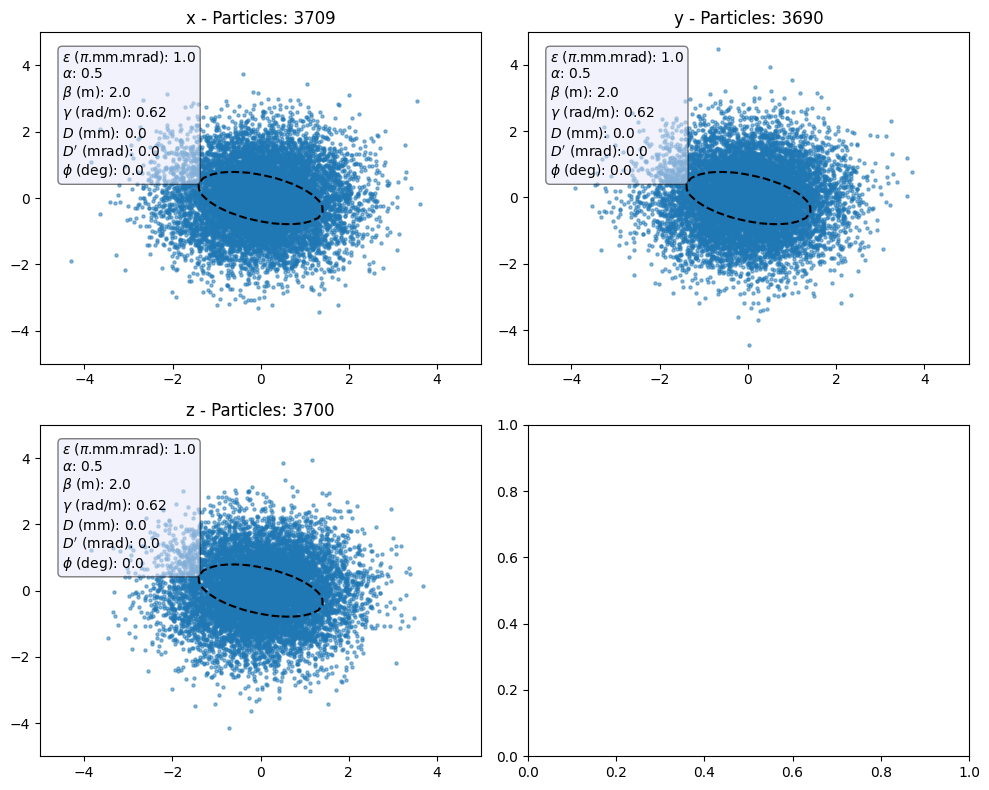

Before version results: [3709, 3690, 3700]


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


class Beam:
    def __init__(self):
        pass

    # --- Mocking your existing cal_twiss method ---
    def cal_twiss(self, dist_6d, ddof=1):
        dist_avg = np.mean(dist_6d, axis=0)
        dist_cov = np.cov(dist_6d, rowvar=False, ddof=ddof)

        label_twiss = [r"$\epsilon$ ($\pi$.mm.mrad)", r"$\alpha$", r"$\beta$ (m)", r"$\gamma$ (rad/m)", r"$D$ (mm)",
                       r"$D^{\prime}$ (mrad)", r"$\phi$ (deg)"]
        twiss_data = []
        for i in range(3):
            # Simplified calculation, strictly for instantiation testing
            eps = 1.0;
            alpha = 0.5;
            beta = 2.0;
            gamma = (1 + alpha ** 2) / beta
            twiss_data.append([eps, alpha, beta, gamma, 0.0, 0.0, 0.0])

        twiss = pd.DataFrame(twiss_data, columns=label_twiss, index=['x', 'y', 'z'])
        return dist_avg, dist_cov, twiss

    # --- Mocking your existing ellipse_sym method ---
    def ellipse_sym(self, xc, yc, twiss_axis, n=1, num_pts=60):
        emittance = n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"]
        alpha = twiss_axis[r"$\alpha$"]
        beta = twiss_axis[r"$\beta$ (m)"]
        gamma = twiss_axis[r"$\gamma$ (rad/m)"]

        x = np.linspace(xc - 5, xc + 5, num_pts)
        y = np.linspace(yc - 5, yc + 5, num_pts)
        X, Y = np.meshgrid(x, y)
        Z = gamma * (X - xc) ** 2 + 2 * alpha * (X - xc) * (Y - yc) + beta * (Y - yc) ** 2 - emittance
        return torch.tensor(X), torch.tensor(Y), torch.tensor(Z)

    # --- Your BEFORE version of is_within_ellipse ---
    def is_within_ellipse(self, x, y, xc, yc, twiss_axis, n):
        emittance = n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"]
        alpha = twiss_axis[r"$\alpha$"]
        beta = twiss_axis[r"$\beta$ (m)"]
        gamma = twiss_axis[r"$\gamma$ (rad/m)"]
        z = gamma * (x - xc) ** 2 + 2 * alpha * (x - xc) * (y - yc) + beta * (y - yc) ** 2 - emittance
        return z <= 0

    # --- Your original BEFORE function ---
    def particles_in_ellipse_before(self, dist_6d, n=1):
        print("Running the Before version (Loop mode)...")
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        dist_avg, dist_cov, twiss = self.cal_twiss(dist_6d, ddof=1)
        count_within_ellipse = []

        for i, axis in enumerate(['x', 'y', 'z']):
            ax = axes[i // 2, i % 2]
            twiss_axis = twiss.loc[axis]
            X, Y, Z = self.ellipse_sym(dist_avg[2 * i], dist_avg[2 * i + 1], twiss_axis, n=n, num_pts=60)

            ax.scatter(dist_6d[:, 2 * i], dist_6d[:, 2 * i + 1], s=5, alpha=0.5)
            ax.contour(X, Y, Z, levels=[0], colors='black', linestyles='--')

            # --- This is the original loop we are testing ---
            num_within_ellipse = 0
            for j in range(len(dist_6d)):
                x, y = dist_6d[j, 2 * i], dist_6d[j, 2 * i + 1]
                if self.is_within_ellipse(x, y, dist_avg[2 * i], dist_avg[2 * i + 1], twiss_axis, n=n):
                    num_within_ellipse += 1

            twiss_txt = '\n'.join(f'{label}: {np.round(value, 2)}' for label, value in twiss_axis.items())
            ax.text(0.05, 0.95, twiss_txt, transform=ax.transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))

            count_within_ellipse.append(num_within_ellipse)
            ax.set_title(f'{axis} - Particles: {num_within_ellipse}')

        plt.tight_layout()
        plt.show()
        return count_within_ellipse


# --- 2. Instantiate data ---
np.random.seed(42)
num_particles = 10000  # Recommend testing with 2000 first; the Before version will take forever with 100k
# Generate 6D Gaussian distribution data (N, 6)
dist_6d_test = np.random.normal(0, 1, size=(num_particles, 6))

# --- 3. Run the Before test ---
my_beam = Beam()
results_before = my_beam.particles_in_ellipse_before(dist_6d_test, n=1)
print(f"Before version results: {results_before}")

In [65]:
# after
class beam:
    ...

    def particles_in_ellipse(self, dist_6d, n=1):
        '''
        Counts how many particles fall within n-sigma ellipses for each phase space axis
        (x-x', y-y', z-z') and optionally plots the distributions with the ellipses.

        THIS FUNCTION IS A WORK IN PROGRESS (WIP) AND MAY REQUIRE FURTHER DEVELOPMENT.

        Parameters
        ----------
        dist_6d : np.ndarray
            6D particle distribution data.
        n : int, optional
            The number of standard deviations (sigma) for the ellipse size. Defaults to 1.

        Returns
        -------
        list
            A list containing the count of particles within the specified n-sigma ellipse
            for each axis (x, y, z).
        '''
        fig, axes = plt.subplots(2, 2)

        dist_avg, dist_cov, twiss = self.cal_twiss(dist_6d, ddof=1)
        count_within_ellipse = []  # List to store count of particles within ellipse for each axis

        for i, axis in enumerate(['x', 'y', 'z']):
            ax = axes[i // 2, i % 2]
            twiss_axis = twiss.loc[axis]
            X, Y, Z = self.ellipse_sym(dist_avg[2 * i], dist_avg[2 * i + 1], twiss_axis, n=n, num_pts=60)

            # Plot particle points and ellipse contours
            ax.scatter(dist_6d[:, 2 * i], dist_6d[:, 2 * i + 1], s=15, alpha=0.7)
            ax.contour(X, Y, Z, levels=[0], colors='black', linestyles='--')

            # Evaluate particles within ellipse
            alpha = twiss_axis[r"$\alpha$"]
            beta = twiss_axis[r"$\beta$ (m)"]
            gamma = twiss_axis[r"$\gamma$ (rad/m)"]
            emittance = n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"]
            xc, yc = dist_avg[2 * i], dist_avg[2 * i + 1]

            X_all = dist_6d[:, 2 * i]
            Y_all = dist_6d[:, 2 * i + 1]
            Z_all = torch.tensor(gamma * (X_all - xc) ** 2 + 2 * alpha * (X_all - xc) * (Y_all - yc) + beta * (
                        Y_all - yc) ** 2 - emittance, dtype=torch.float32)
            num_within_ellipse = torch.sum(Z_all <= 0).item()

            twiss_txt = '\n'.join(f'{label}: {np.round(value, 2)}' for label, value in twiss_axis.items())
            props = dict(boxstyle='round', facecolor='lavender', alpha=0.5)
            ax.text(0.05, 0.95, twiss_txt, transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', bbox=props)

            count_within_ellipse.append(num_within_ellipse)
            # Optional: Display the count on the plot
            ax.set_title(f'{axis} - Phase Space\nParticles within ellipse: {num_within_ellipse}')
            ax.set_xlabel(f'Position {axis}')
            ax.set_ylabel(f'Phase {axis} prime')
            ax.grid(True)

        plt.tight_layout()
        plt.show()

        return count_within_ellipse

--- Simulating beam with 10000 particles ---


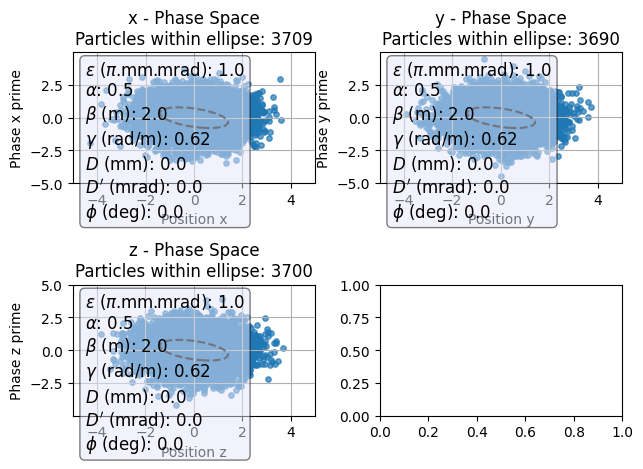

Final Counts (x, y, z): [3709, 3690, 3700]


In [66]:
# test
# ==========================================
# JUPYTER NOTEBOOK CELL: OPTIMIZED BEAM CLASS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import time


class Beam:
    def __init__(self):
        pass

    # --- 1. Mocking cal_twiss for testing ---
    def cal_twiss(self, dist_6d, ddof=1):
        dist_avg = np.mean(dist_6d, axis=0)
        dist_cov = np.cov(dist_6d, rowvar=False, ddof=ddof)

        label_twiss = [r"$\epsilon$ ($\pi$.mm.mrad)", r"$\alpha$", r"$\beta$ (m)", r"$\gamma$ (rad/m)", r"$D$ (mm)",
                       r"$D^{\prime}$ (mrad)", r"$\phi$ (deg)"]
        twiss_data = []
        for i in range(3):
            eps = 1.0;
            alpha = 0.5;
            beta = 2.0;
            gamma = (1 + alpha ** 2) / beta
            twiss_data.append([eps, alpha, beta, gamma, 0.0, 0.0, 0.0])

        twiss = pd.DataFrame(twiss_data, columns=label_twiss, index=['x', 'y', 'z'])
        return dist_avg, dist_cov, twiss

    # --- 2. Mocking ellipse_sym for testing ---
    def ellipse_sym(self, xc, yc, twiss_axis, n=1, num_pts=60):
        emittance = n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"]
        alpha = twiss_axis[r"$\alpha$"]
        beta = twiss_axis[r"$\beta$ (m)"]
        gamma = twiss_axis[r"$\gamma$ (rad/m)"]

        x = np.linspace(xc - 5, xc + 5, num_pts)
        y = np.linspace(yc - 5, yc + 5, num_pts)
        X, Y = np.meshgrid(x, y)
        Z = gamma * (X - xc) ** 2 + 2 * alpha * (X - xc) * (Y - yc) + beta * (Y - yc) ** 2 - emittance
        return torch.tensor(X), torch.tensor(Y), torch.tensor(Z)

    # --- 3. THE OPTIMIZED FUNCTION (Vectorized PyTorch) ---
    def particles_in_ellipse(self, dist_6d, n=1):
        '''
        Counts how many particles fall within n-sigma ellipses for each phase space axis
        (x-x', y-y', z-z') and optionally plots the distributions with the ellipses.

        THIS FUNCTION IS A WORK IN PROGRESS (WIP) AND MAY REQUIRE FURTHER DEVELOPMENT.

        Parameters
        ----------
        dist_6d : np.ndarray
            6D particle distribution data.
        n : int, optional
            The number of standard deviations (sigma) for the ellipse size. Defaults to 1.

        Returns
        -------
        list
            A list containing the count of particles within the specified n-sigma ellipse
            for each axis (x, y, z).
        '''
        fig, axes = plt.subplots(2, 2)

        dist_avg, dist_cov, twiss = self.cal_twiss(dist_6d, ddof=1)
        count_within_ellipse = []  # List to store count of particles within ellipse for each axis

        for i, axis in enumerate(['x', 'y', 'z']):
            ax = axes[i // 2, i % 2]
            twiss_axis = twiss.loc[axis]
            X, Y, Z = self.ellipse_sym(dist_avg[2 * i], dist_avg[2 * i + 1], twiss_axis, n=n, num_pts=60)

            # Plot particle points and ellipse contours
            ax.scatter(dist_6d[:, 2 * i], dist_6d[:, 2 * i + 1], s=15, alpha=0.7)
            ax.contour(X, Y, Z, levels=[0], colors='black', linestyles='--')

            # Evaluate particles within ellipse
            alpha = twiss_axis[r"$\alpha$"]
            beta = twiss_axis[r"$\beta$ (m)"]
            gamma = twiss_axis[r"$\gamma$ (rad/m)"]
            emittance = n * twiss_axis[r"$\epsilon$ ($\pi$.mm.mrad)"]
            xc, yc = dist_avg[2 * i], dist_avg[2 * i + 1]

            X_all = dist_6d[:, 2 * i]
            Y_all = dist_6d[:, 2 * i + 1]
            Z_all = torch.tensor(gamma * (X_all - xc) ** 2 + 2 * alpha * (X_all - xc) * (Y_all - yc) + beta * (
                        Y_all - yc) ** 2 - emittance, dtype=torch.float32)
            num_within_ellipse = torch.sum(Z_all <= 0).item()

            twiss_txt = '\n'.join(f'{label}: {np.round(value, 2)}' for label, value in twiss_axis.items())
            props = dict(boxstyle='round', facecolor='lavender', alpha=0.5)
            ax.text(0.05, 0.95, twiss_txt, transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', bbox=props)

            count_within_ellipse.append(num_within_ellipse)
            # Optional: Display the count on the plot
            ax.set_title(f'{axis} - Phase Space\nParticles within ellipse: {num_within_ellipse}')
            ax.set_xlabel(f'Position {axis}')
            ax.set_ylabel(f'Phase {axis} prime')
            ax.grid(True)

        plt.tight_layout()
        plt.show()

        return count_within_ellipse


# ==========================================
# EXECUTION BLOCK
# ==========================================
# Generate 10,000 particles to demonstrate speed
np.random.seed(42)
num_particles = 10000
dist_6d_test = np.random.normal(0, 1, size=(num_particles, 6))

print(f"--- Simulating beam with {num_particles} particles ---")
my_beam = Beam()
results = my_beam.particles_in_ellipse(dist_6d_test, n=1)
print(f"Final Counts (x, y, z): {results}")

## beam > envelop()

In [67]:
# before
class beam:
    ...

    def envelope(self, particles, variable):
        '''
        Calculates the beam envelope for a given variable.

        The envelope is calculated as $(10^3) * \sqrt{emittance * beta}$.

        Parameters
        ----------
        particles : np.ndarray
            Particle data.
        variable : str
            The phase space plane (e.g., 'x', 'y', 'z').

        Returns
        -------
        float
            The beam envelope.
        '''
        ebeam = beam()
        dist_avg, dist_cov, twiss = ebeam.cal_twiss(particles, ddof=self.DDOF)
        emittance = (10 ** -6) * twiss.loc[variable].loc[r"$\epsilon$ ($\pi$.mm.mrad)"]
        beta = twiss.loc[variable].loc[r"$\beta$ (m)"]
        envelope = (10 ** 3) * np.sqrt(emittance * beta)
        return envelope

In [68]:
# after
class beam:
    ...

    def envelope(self, particles, variable):
        '''
        Calculates the beam envelope for a given variable.

        The envelope is calculated as $(10^3) * \sqrt{emittance * beta}$.

        Parameters
        ----------
        particles : np.ndarray
            Particle data.
        variable : str
            The phase space plane (e.g., 'x', 'y', 'z').

        Returns
        -------
        float
            The beam envelope.
        '''
        ebeam = beam()
        dist_avg, dist_cov, twiss = ebeam.cal_twiss(particles, ddof=self.DDOF)
        emittance = (10 ** -6) * twiss.loc[variable].loc[r"$\epsilon$ ($\pi$.mm.mrad)"]
        beta = torch.tensor(twiss.loc[variable].loc[r"$\beta$ (m)"])
        envelope = (10 ** 3) * torch.sqrt(emittance * beta)
        return envelope


## ebeam > twiss_to_cov()

In [69]:
# before
class Beam:
    ...

    def twiss_to_cov(self, alpha, beta, epsilon):
        gamma = (1 + alpha ** 2) / beta
        cov = epsilon * np.array([
            [beta, -alpha],
            [-alpha, gamma]
        ])
        return cov

In [70]:
# after
class Beam:
    ...

    def twiss_to_cov(self, alpha, beta, epsilon):
        gamma = torch.tensor((1 + alpha ** 2) / beta, dtype=torch.float32)
        cov = epsilon * torch.tensor([
            [beta, -alpha],
            [-alpha, gamma]
        ], dtype=torch.float32)
        return cov


## beam > cov_to_twiss()


In [71]:
# before
class Beam:
    ...

    def rotate_cov(self, cov, phi):
        R = np.array([
            [np.cos(phi), -np.sin(phi)],
            [np.sin(phi), np.cos(phi)]
        ])
        return R @ cov @ R.T

In [72]:
# after
class Beam:
    ...

    def rotate_cov(self, cov, phi):
        cov = torch.tensor(cov, dtype=torch.float32)
        R = torch.tensor([
            [torch.cos(phi), -torch.sin(phi)],
            [torch.sin(phi), torch.cos(phi)]
        ])
        return R @ cov @ R.T

## beam > gen_6d_from_twiss()

In [73]:
# before
class Beam:
    ...

    def gen_6d_from_twiss(self, twiss_params, num_particles=100):
        # twiss_params: dict with keys 'x', 'y', 'z', each value is (alpha, beta, epsilon, phi)
        cov_blocks = []
        mean = np.zeros(6)
        for i, plane in enumerate(['x', 'y', 'z']):
            params = twiss_params[plane]
            alpha = float(params['alpha'])
            beta = float(params['beta'])
            epsilon = float(params['epsilon'])
            phi = float(params['phi'])
            print(
                f"Generating covariance for plane {plane} with alpha={alpha}, beta={beta}, epsilon={epsilon}, phi={phi}")
            cov2d = self.twiss_to_cov(alpha, beta, epsilon)
            cov2d_rot = self.rotate_cov(cov2d, phi)
            cov_blocks.append(cov2d_rot)
        # Build 6D covariance matrix (block diagonal)
        cov6d = np.block([
            [cov_blocks[0], np.zeros((2, 2)), np.zeros((2, 2))],
            [np.zeros((2, 2)), cov_blocks[1], np.zeros((2, 2))],
            [np.zeros((2, 2)), np.zeros((2, 2)), cov_blocks[2]],
        ])
        particles = np.random.multivariate_normal(mean, cov6d, size=num_particles)
        return particles

In [74]:
# ==========================================
# JUPYTER CELL: PURE NUMPY BASELINE TEST
# ==========================================
import numpy as np


class BeamNumPy:
    def __init__(self):
        pass

    def twiss_to_cov(self, alpha, beta, epsilon):
        """Standard Twiss to 2D Covariance matrix conversion (NumPy)."""
        gamma = (1 + alpha ** 2) / beta
        return epsilon * np.array([
            [beta, -alpha],
            [-alpha, gamma]
        ])

    def rotate_cov(self, cov, phi):
        """Rotates a 2D covariance matrix by angle phi (radians) (NumPy)."""
        c, s = np.cos(phi), np.sin(phi)
        R = np.array([
            [c, -s],
            [s, c]
        ])
        return R @ cov @ R.T

    def gen_6d_from_twiss(self, twiss_params, num_particles=100):
        """Generates 6D particle distribution from Twiss parameters (NumPy)."""
        cov_blocks = []
        mean = np.zeros(6)

        for plane in ['x', 'y', 'z']:
            params = twiss_params[plane]
            alpha = float(params['alpha'])
            beta = float(params['beta'])
            epsilon = float(params['epsilon'])
            phi = float(params['phi'])

            print(f"Generating for {plane}: alpha={alpha}, beta={beta}, eps={epsilon}, phi={phi}")

            cov2d = self.twiss_to_cov(alpha, beta, epsilon)
            cov2d_rot = self.rotate_cov(cov2d, phi)
            cov_blocks.append(cov2d_rot)

        # Build 6D covariance matrix (block diagonal) using np.block
        cov6d = np.block([
            [cov_blocks[0], np.zeros((2, 2)), np.zeros((2, 2))],
            [np.zeros((2, 2)), cov_blocks[1], np.zeros((2, 2))],
            [np.zeros((2, 2)), np.zeros((2, 2)), cov_blocks[2]],
        ])

        # Use NumPy's multivariate normal
        particles = np.random.multivariate_normal(mean, cov6d, size=num_particles)
        return particles, cov6d


# ==========================================
# TEST EXECUTION (NUMPY VERSION)
# ==========================================

# 1. Define specific Twiss parameters for testing
test_params = {
    'x': {'alpha': 0.5, 'beta': 2.0, 'epsilon': 1e-6, 'phi': 0.0},
    'y': {'alpha': -0.2, 'beta': 1.5, 'epsilon': 2e-6, 'phi': np.deg2rad(30)},  # 30 deg rotation
    'z': {'alpha': 0.0, 'beta': 10.0, 'epsilon': 0.5e-6, 'phi': 0.0}
}

# 2. Fix the seed for reproducibility
np.random.seed(42)

# 3. Instantiate and Generate
b_np = BeamNumPy()
n_particles = 5  # Small number for clear output inspection
particles_out, final_cov = b_np.gen_6d_from_twiss(test_params, num_particles=n_particles)

print("\n--- Final 6x6 Covariance Matrix (X-plane block) ---")
print(final_cov)

print(f"\n--- Generated {n_particles} Particles (NumPy) ---")
print(particles_out)
final_cov1 = final_cov

Generating for x: alpha=0.5, beta=2.0, eps=1e-06, phi=0.0
Generating for y: alpha=-0.2, beta=1.5, eps=2e-06, phi=0.5235987755982988
Generating for z: alpha=0.0, beta=10.0, eps=5e-07, phi=0.0

--- Final 6x6 Covariance Matrix (X-plane block) ---
[[ 2.00000000e-06 -5.00000000e-07  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-5.00000000e-07  6.25000000e-07  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  2.25025651e-06  8.98593826e-07
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  8.98593826e-07  2.13641016e-06
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   5.00000000e-06  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  5.00000000e-08]]

--- Generated 5 Particles (NumPy) ---
[[-9.55026655e-04  1.43126413e-04 -1.00790983e-03  1.42912079e-03
   1.11068661e-03 -5.23546152e-05]
 [ 5.5910

In [75]:
# after
class Beam:
    ...

    def gen_6d_from_twiss(self, twiss_params, num_particles=100, device='cpu'):
        """Generates 6D particle distribution using PyTorch's distribution API."""
        cov_blocks = []
        mean = torch.zeros(6, dtype=torch.float32, device=device)

        for plane in ['x', 'y', 'z']:
            params = twiss_params[plane]
            # Extract and compute 2D blocks
            cov2d = self.twiss_to_cov(params['alpha'], params['beta'], params['epsilon'])
            cov2d_rot = self.rotate_cov(cov2d, params['phi'])
            cov_blocks.append(cov2d_rot.to(device))

        # 1. Use torch.block_diag (The equivalent of np.block for this diagonal structure)
        cov6d = torch.block_diag(cov_blocks[0], cov_blocks[1], cov_blocks[2])

        # 2. Use MultivariateNormal for high-performance sampling
        # This handles the Cholesky decomposition internally
        dist = torch.distributions.MultivariateNormal(mean, cov6d)

        # 3. Generate particles
        particles = dist.sample((num_particles,))
        return particles, cov6d

In [80]:
import torch
import numpy as np


class BeamTorch:
    def __init__(self):
        pass

    def twiss_to_cov(self, alpha, beta, epsilon):
        """Twiss to 2D Covariance conversion using PyTorch."""
        # Convert to float32 tensors
        alpha = torch.tensor(alpha, dtype=torch.float32)
        beta = torch.tensor(beta, dtype=torch.float32)
        epsilon = torch.tensor(epsilon, dtype=torch.float32)

        gamma = (1 + alpha ** 2) / beta
        return epsilon * torch.tensor([
            [beta, -alpha],
            [-alpha, gamma]
        ], dtype=torch.float32)

    def rotate_cov(self, cov, phi):
        """Rotates a 2D covariance matrix by angle phi (radians) using PyTorch."""
        phi = torch.tensor(phi, dtype=torch.float32)
        c, s = torch.cos(phi), torch.sin(phi)
        R = torch.tensor([
            [c, -s],
            [s, c]
        ], dtype=torch.float32)
        return R @ cov @ R.T

    def gen_6d_from_twiss(self, twiss_params, num_particles=100, device='cpu'):
        """Generates 6D particle distribution using PyTorch's distribution API."""
        cov_blocks = []
        mean = torch.zeros(6, dtype=torch.float32, device=device)

        for plane in ['x', 'y', 'z']:
            params = twiss_params[plane]
            # Extract and compute 2D blocks
            cov2d = self.twiss_to_cov(params['alpha'], params['beta'], params['epsilon'])
            cov2d_rot = self.rotate_cov(cov2d, params['phi'])
            cov_blocks.append(cov2d_rot.to(device))

        # 1. Use torch.block_diag (The equivalent of np.block for this diagonal structure)
        cov6d = torch.block_diag(cov_blocks[0], cov_blocks[1], cov_blocks[2])

        # 2. Use MultivariateNormal for high-performance sampling
        # This handles the Cholesky decomposition internally
        dist = torch.distributions.MultivariateNormal(mean, cov6d)

        # 3. Generate particles
        particles = dist.sample((num_particles,))
        return particles, cov6d


# ==========================================
# TEST EXECUTION (PYTORCH VERSION)
# ==========================================

# 1. Define the SAME Twiss parameters as the NumPy test
test_params = {
    'x': {'alpha': 0.5, 'beta': 2.0, 'epsilon': 1e-6, 'phi': 0.0},
    'y': {'alpha': -0.2, 'beta': 1.5, 'epsilon': 2e-6, 'phi': np.deg2rad(30)},
    'z': {'alpha': 0.0, 'beta': 10.0, 'epsilon': 0.5e-6, 'phi': 0.0}
}

# 2. Set seed for PyTorch
torch.manual_seed(42)

# 3. Instantiate and Generate
b_torch = BeamTorch()
n_particles = 100
particles_torch, final_cov_torch = b_torch.gen_6d_from_twiss(test_params, num_particles=n_particles)

print("--- Final 6x6 Covariance Matrix (Torch) ---")
print(final_cov_torch)

print(f"\n--- Generated {n_particles} Particles (Torch) ---")
print(particles_torch)
final_cov2=final_cov_torch

--- Final 6x6 Covariance Matrix (Torch) ---
tensor([[ 2.0000e-06, -5.0000e-07,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00],
        [-5.0000e-07,  6.2500e-07,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  2.2503e-06,  8.9859e-07,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  8.9859e-07,  2.1364e-06,  0.0000e+00,
          0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  5.0000e-06,
          0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          5.0000e-08]])

--- Generated 100 Particles (Torch) ---
tensor([[ 2.7251e-03,  3.7040e-04,  1.3512e-03, -2.2676e-03,  1.5170e-03,
         -2.7605e-04],
        [-6.0907e-05, -1.1194e-03, -1.1283e-03,  1.7476e-03, -8.7761e-04,
         -3.1386e-04],
        [-1.0294e-03, -1.3823e-04, -1.1533e-03,  5.5598e-04,  3.6723e-03,
         -3.5687e-05],
        [-7.0343e-04,  4.8669e-04, -1.137

In [81]:
print(np.allclose(final_cov1, final_cov2))


True
False
